In [ ]:
import subprocess
import os
import csv
import statistics
 
os.makedirs("results", exist_ok=True)
 
urls_file = "urls.txt"
keyword = "fakulteta"
 
def parse_times(stdout):
    times = []
 
    for line in stdout.splitlines():
        line = line.strip()
 
        if line.startswith("Run"):
            parts = line.split(":")
            run_number = int(parts[0].split()[1])
            elapsed_time = float(parts[1].split()[0])
            times.append((run_number, elapsed_time))
    return times
 
 
def save_csv(csv_path, rows):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "program",
            "run_number",
            "elapsed_time_s",
            "nprocs"
        ])
        writer.writerows(rows)
 
 
def print_summary(program, times, nprocs):
    values = [t for _, t in times]
    avg = statistics.mean(values)
    std = statistics.stdev(values) if len(values) > 1 else 0.0
    min_time = min(values)
    max_time = max(values)
 
    print(f"\n--- Povzetek: {program}, nprocs={nprocs} ---")
    print(f"Povprečni čas:      {avg:.4f} s")
    print(f"Standardni odklon:  {std:.4f} s")
    print(f"Minimalni čas:      {min_time:.4f} s")
    print(f"Maksimalni čas:     {max_time:.4f} s")
 
 
# 1) Serial
script = "WebScraperSerial.py"
csv_path = os.path.join("results", "WebScraperSerial.csv")
 
print(f"\nRunning {script}")
 
cmd = ["python", script, urls_file, keyword]
result = subprocess.run(cmd, capture_output=True, text=True)
 
print(result.stdout)
 
if result.stderr:
    print("STDERR:")
    print(result.stderr)
 
times = parse_times(result.stdout)
 
rows = []
for run_number, elapsed_time in times:
    rows.append([script, run_number, elapsed_time, 1])
 
save_csv(csv_path, rows)
print_summary(script, times, 1)
 
print(f"Shranjeno: {csv_path}")
 
 
# 2) Numba
script = "WebSerialNumba.py"
csv_path = os.path.join("results", "WebSerialNumba.csv")
 
print(f"\nRunning {script}")
 
cmd = ["python", script, urls_file, keyword]
result = subprocess.run(cmd, capture_output=True, text=True)
 
print(result.stdout)
 
if result.stderr:
    print("STDERR:")
    print(result.stderr)
 
times = parse_times(result.stdout)
 
rows = []
for run_number, elapsed_time in times:
    rows.append([script, run_number, elapsed_time, 1])
 
save_csv(csv_path, rows)
print_summary(script, times, 1)
 
print(f"Shranjeno: {csv_path}")
 
 
# 3) MPI
script = "WebScraperMPI.py"
csv_path = os.path.join("results", "WebScraperMPI.csv")
 
all_mpi_rows = []
 
for nprocs in [1, 2, 4, 8]:
    print(f"\nRunning {script} with {nprocs} processes")
 
    cmd = [
        "mpiexec",
        "-n",
        str(nprocs),
        "python",
        script,
        urls_file,
        keyword
    ]
 
    result = subprocess.run(cmd, capture_output=True, text=True)
 
    print(result.stdout)
 
    if result.stderr:
        print("STDERR:")
        print(result.stderr)
 
    times = parse_times(result.stdout)
 
    for run_number, elapsed_time in times:
        all_mpi_rows.append([script, run_number, elapsed_time, nprocs])
 
    print_summary(script, times, nprocs)
 
save_csv(csv_path, all_mpi_rows)
 
print(f"Shranjeno: {csv_path}")


Running WebScraperSerial.py
Run  1: 3.5635 s
Run  2: 2.0895 s
Run  3: 4.8005 s
Run  4: 3.4262 s
Run  5: 1.7727 s
Run  6: 1.6342 s
Run  7: 2.9053 s
Run  8: 3.8605 s
Run  9: 5.8487 s
Run 10: 5.2022 s

--- Povzetek ÄŤasa ---
Povprecni cas: 3.5103 s
Standardni odklon: 1.3803 s
Minimalni cas: 1.6342 s
Maximalni cas: 5.8487 s


--- Povzetek: WebScraperSerial.py, nprocs=1 ---
Povprečni čas:      3.5103 s
Standardni odklon:  1.4549 s
Minimalni čas:      1.6342 s
Maksimalni čas:     5.8487 s
Shranjeno: results\WebScraperSerial.csv

Running WebSerialNumba.py
Run  1: 2.8667 s
Run  2: 3.3509 s
Run  3: 5.6749 s
Run  4: 4.4140 s
Run  5: 4.5766 s
Run  6: 2.6587 s
Run  7: 5.0066 s
Run  8: 2.5561 s
Run  9: 3.3739 s
Run 10: 2.9338 s

--- Povzetek casa ---
Povprecni cas: 3.7412 s
Standardni odklon: 1.0379 s
Minimalni cas: 2.5561 s
Maximalni cas: 5.6749 s


--- Povzetek: WebSerialNumba.py, nprocs=1 ---
Povprečni čas:      3.7412 s
Standardni odklon:  1.0940 s
Minimalni čas:      2.5561 s
Maksimalni čas: 

# Rezultati - graf

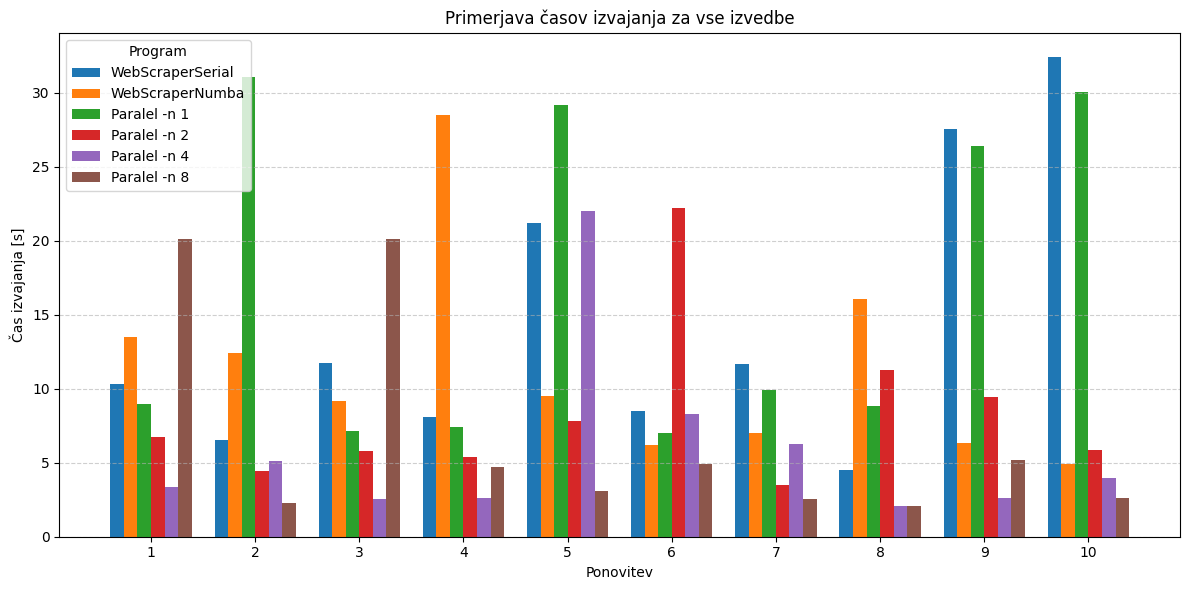

In [1]:
import matplotlib.pyplot as plt
import numpy as np

runs = np.arange(1, 11)

serial_times = [
    10.3408, 6.5452, 11.7637, 8.0689, 21.1912,
    8.5211, 11.6378, 4.5327, 27.5694, 32.4188
]

numba_times = [
    13.4638, 12.4312, 9.1736, 28.4886, 9.5028,
    6.2020, 7.0170, 16.0390, 6.3457, 4.9015
]

paralel1_times = [
    8.9528, 31.0302, 7.1745, 7.3963, 29.1958,
    7.0074, 9.8941, 8.7986, 26.3748, 30.0195
]

paralel2_times = [
    6.7595, 4.4677, 5.8108, 5.3822, 7.8381,
    22.2258, 3.4665, 11.2418, 9.4522, 5.8829
]

paralel4_times = [
    3.3667, 5.1259, 2.5160, 2.6472, 22.0231,
    8.2684, 6.2474, 2.0591, 2.6287, 3.9979
]

paralel8_times = [
    20.1285, 2.2893, 20.1372, 4.7115, 3.1213,
    4.8978, 2.5403, 2.0565, 5.1622, 2.6060
]

width = 0.13
x = np.arange(len(runs))

plt.figure(figsize=(12, 6))

plt.bar(x - 2.5 * width, serial_times, width=width, label='WebScraperSerial')
plt.bar(x - 1.5 * width, numba_times, width=width, label='WebScraperNumba')
plt.bar(x - 0.5 * width, paralel1_times, width=width, label='Paralel -n 1')
plt.bar(x + 0.5 * width, paralel2_times, width=width, label='Paralel -n 2')
plt.bar(x + 1.5 * width, paralel4_times, width=width, label='Paralel -n 4')
plt.bar(x + 2.5 * width, paralel8_times, width=width, label='Paralel -n 8')

plt.xlabel("Ponovitev")
plt.ylabel("Čas izvajanja [s]")
plt.title("Primerjava časov izvajanja za vse izvedbe")
plt.xticks(x, runs)
plt.legend(title="Program")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

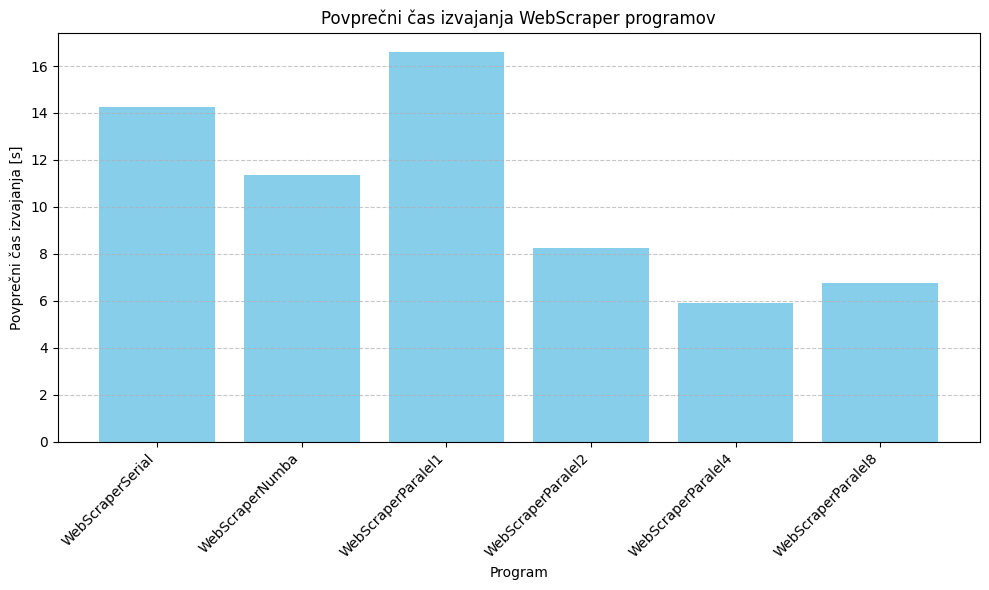

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# Seznam CSV-jev
csv_files = [
    "results/WebScraperSerial.csv",
    "results/WebScraperNumba.csv",
    "results/WebScraperParalel1.csv",
    "results/WebScraperParalel2.csv",
    "results/WebScraperParalel4.csv",
    "results/WebScraperParalel8.csv"
]

# Funkcija za branje časov iz datotek
def parse_scraper_csv(file_path):
    times = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.match(r"Run\s+\d+:\s+([\d\.]+)\s+s", line)
            if match:
                times.append(float(match.group(1)))
    return times

# Izračun povprečnih časov
summary = {}
for csv_file in csv_files:
    times = parse_scraper_csv(csv_file)
    avg_time = sum(times) / len(times) if times else 0
    summary[os.path.basename(csv_file).replace(".csv","")] = avg_time

# Nariši graf povprečnih časov
plt.figure(figsize=(10,6))
bars = plt.bar(summary.keys(), summary.values(), color='skyblue')
plt.ylabel("Povprečni čas izvajanja [s]")
plt.xlabel("Program")
plt.title("Povprečni čas izvajanja WebScraper programov")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Nagnjeni x-tick labeli
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Skupni rezultati izvedb

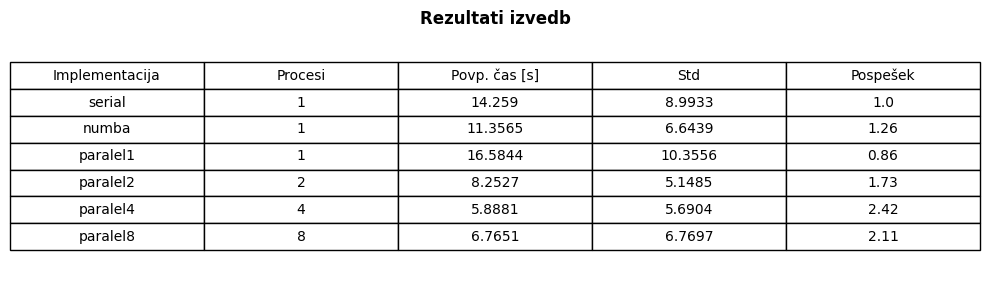

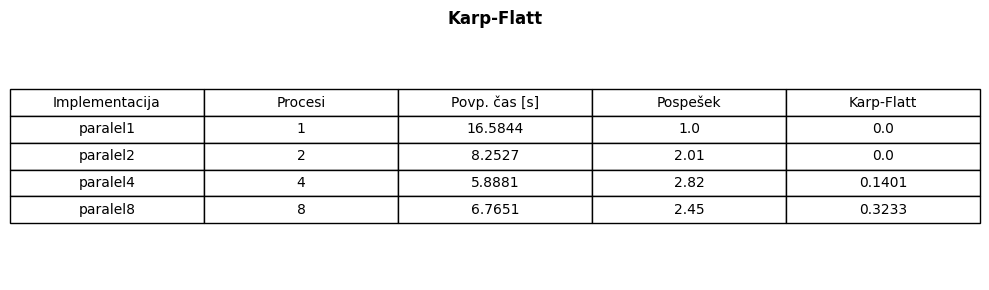

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_left = pd.DataFrame({
    "Implementacija": ["serial", "numba", "paralel1", "paralel2", "paralel4", "paralel8"],
    "Procesi": [1, 1, 1, 2, 4, 8],
    "Povp. čas [s]": [14.2590, 11.3565, 16.5844, 8.2527, 5.8881, 6.7651],
    "Std": [8.9933, 6.6439, 10.3556, 5.1485, 5.6904, 6.7697]
})

# Pospešek glede na serial izvedbo
serial_base = df_left.loc[df_left["Implementacija"] == "serial", "Povp. čas [s]"].iloc[0]
df_left["Pospešek"] = serial_base / df_left["Povp. čas [s]"]

# Paralelne izvedbe za Karp-Flatt analizo
df_right = df_left[df_left["Implementacija"].isin(
    ["paralel1", "paralel2", "paralel4", "paralel8"]
)].copy()

# Pospešek glede na paralel1
paralel_base = df_right.loc[df_right["Implementacija"] == "paralel1", "Povp. čas [s]"].iloc[0]
df_right["Pospešek"] = paralel_base / df_right["Povp. čas [s]"]

def karp_flatt(S, p):
    if p == 1:
        return 0.0

    e = (1 / S - 1 / p) / (1 - 1 / p)

    # Negativna vrednost pomeni superlinearni pospešek oziroma merilni šum.
    # Za interpretacijo serijskega deleža jo omejimo na 0.
    return max(0.0, e)

df_right["Karp-Flatt"] = [
    karp_flatt(S, p)
    for S, p in zip(df_right["Pospešek"], df_right["Procesi"])
]

df_left_display = df_left.round({
    "Povp. čas [s]": 4,
    "Std": 4,
    "Pospešek": 2
})

df_right_display = df_right[[
    "Implementacija",
    "Procesi",
    "Povp. čas [s]",
    "Pospešek",
    "Karp-Flatt"
]].round({
    "Povp. čas [s]": 4,
    "Pospešek": 2,
    "Karp-Flatt": 4
})

def save_table_image(df, filename, title):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

save_table_image(df_left_display, "levi_del_tabele.png", "Rezultati izvedb")
save_table_image(df_right_display, "desni_del_tabele.png", "Karp-Flatt")

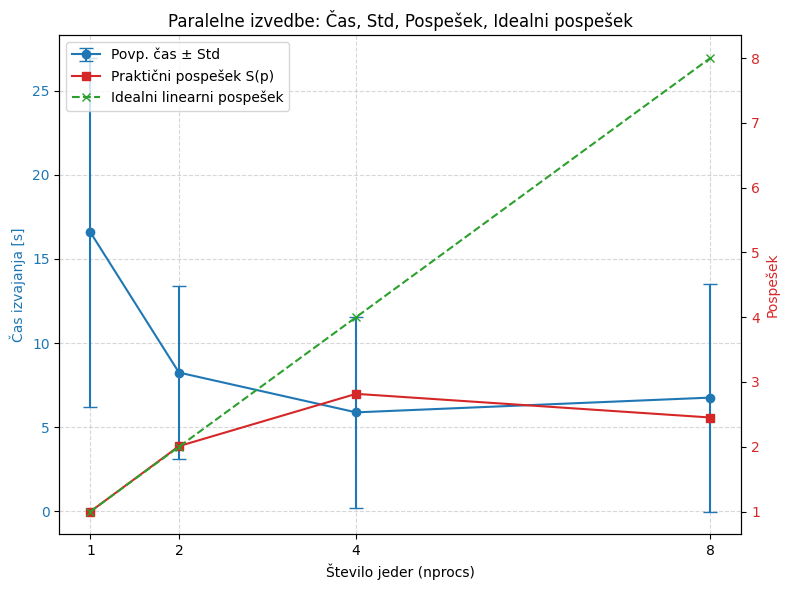

In [6]:
import matplotlib.pyplot as plt
import numpy as np
 
# Podatki za paralelne izvedbe
nprocs = np.array([1, 2, 4, 8])
avg_time = np.array([16.5844, 8.2527, 5.8881, 6.7651])
std = np.array([10.3556, 5.1485, 5.6904, 6.7697])
 
S_p = avg_time[0] / avg_time
S_ideal = nprocs  # idealni linearni pospešek
 
# Karp-Flatt
e_p = np.zeros_like(nprocs, dtype=float)
for i, p in enumerate(nprocs):
    if p == 1:
        e_p[i] = 0.0
    else:
        e_p[i] = (1/S_p[i] - 1/p) / (1 - 1/p)

fig, ax1 = plt.subplots(figsize=(8,6))
 
# Povprečni čas in std
color = 'tab:blue'
ax1.set_xlabel('Število jeder (nprocs)')
ax1.set_ylabel('Čas izvajanja [s]', color=color)
ax1.errorbar(nprocs, avg_time, yerr=std, fmt='o-', color=color, capsize=5, label='Povp. čas ± Std')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(nprocs)
ax1.grid(True, linestyle='--', alpha=0.5)
 
# Praktični pospešek in idealni pospešek 
ax2 = ax1.twinx()
ax2.set_ylabel('Pospešek', color='tab:red')
ax2.plot(nprocs, S_p, 's-', color='tab:red', label='Praktični pospešek S(p)')
ax2.plot(nprocs, S_ideal, 'x--', color='tab:green', label='Idealni linearni pospešek')
ax2.tick_params(axis='y', labelcolor='tab:red')
 
# Legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.title('Paralelne izvedbe: Čas, Std, Pospešek, Idealni pospešek')
plt.tight_layout()
plt.show()
 

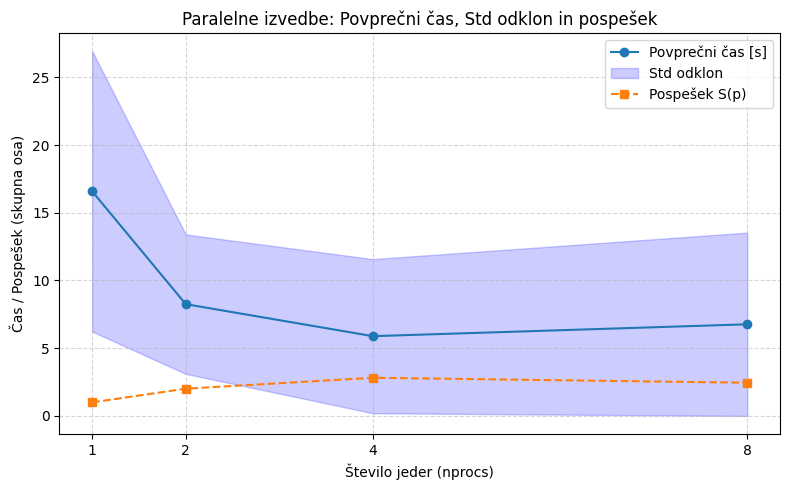

In [7]:
import matplotlib.pyplot as plt
import numpy as np

nprocs = np.array([1, 2, 4, 8])
avg_time = np.array([16.5844, 8.2527, 5.8881, 6.7651])
std = np.array([10.3556, 5.1485, 5.6904, 6.7697])
S_p = avg_time[0] / avg_time

plt.figure(figsize=(8,5))

plt.plot(nprocs, avg_time, 'o-', label='Povprečni čas [s]')
plt.fill_between(nprocs, avg_time - std, avg_time + std, color='blue', alpha=0.2, label='Std odklon')
plt.plot(nprocs, S_p, 's--', label='Pospešek S(p)')

plt.xlabel('Število jeder (nprocs)')
plt.ylabel('Čas / Pospešek (skupna osa)')
plt.title('Paralelne izvedbe: Povprečni čas, Std odklon in pospešek')
plt.xticks(nprocs)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()